In [1]:
import os
import sys
import sys
from pathlib import Path


import h5py
import hdf5plugin
import numpy as np
from pathlib import Path
from diffractom import SinglePhaseForwardOperator
import yaml

import pyopencl.array as clarray
from diffractom import Grid
from diffractom import Material
import matplotlib.pyplot as plt

# ---------------------------
# CREATE RUN FOLDER
# ---------------------------

RECON_PATH  = Path('/work3/msaca/textomo_run_026/reconstruction.h5')
OUT_DIR = Path('/work3/msaca/textomo_run_026/detector_plots')
OUT_DIR.mkdir(parents=True, exist_ok=True)


print("Saving results to:", OUT_DIR)

# ------------------    ---------
# CONFIG
# ---------------------------
config_path = "/zhome/71/c/146676/texture_tomography/" + "configs/" + "aluminum_config.yaml"

with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

N_eta = cfg['N_eta']
N_Omega = cfg['N_Omega']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
My = cfg['My']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']



Saving results to: /work3/msaca/textomo_run_026/detector_plots


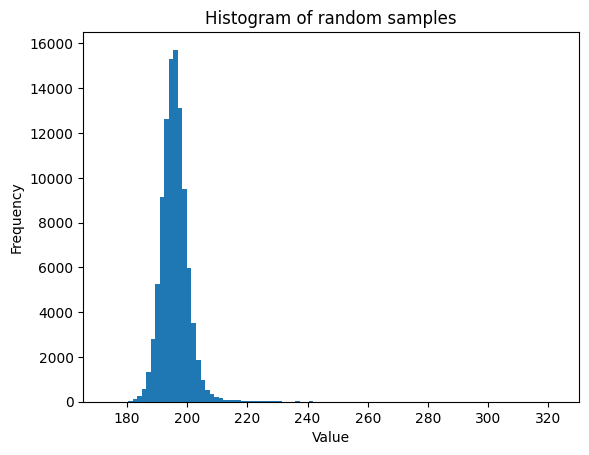

In [58]:
N = 150

with h5py.File(datapath + "scan-0199_orca.h5", 'r') as f:
    dataset = f['entry/instrument/orca/data']
    detector_image = dataset[N-4:N+4].mean(axis=0)


# arr = your large 2D array

n_samples = 100_000

# Flatten index sampling (memory-efficient)
flat_indices = np.random.choice(detector_image.size, size=n_samples, replace=False)
samples = detector_image.ravel()[flat_indices]

# Plot histogram
plt.hist(samples, bins=100)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of random samples")
plt.show()

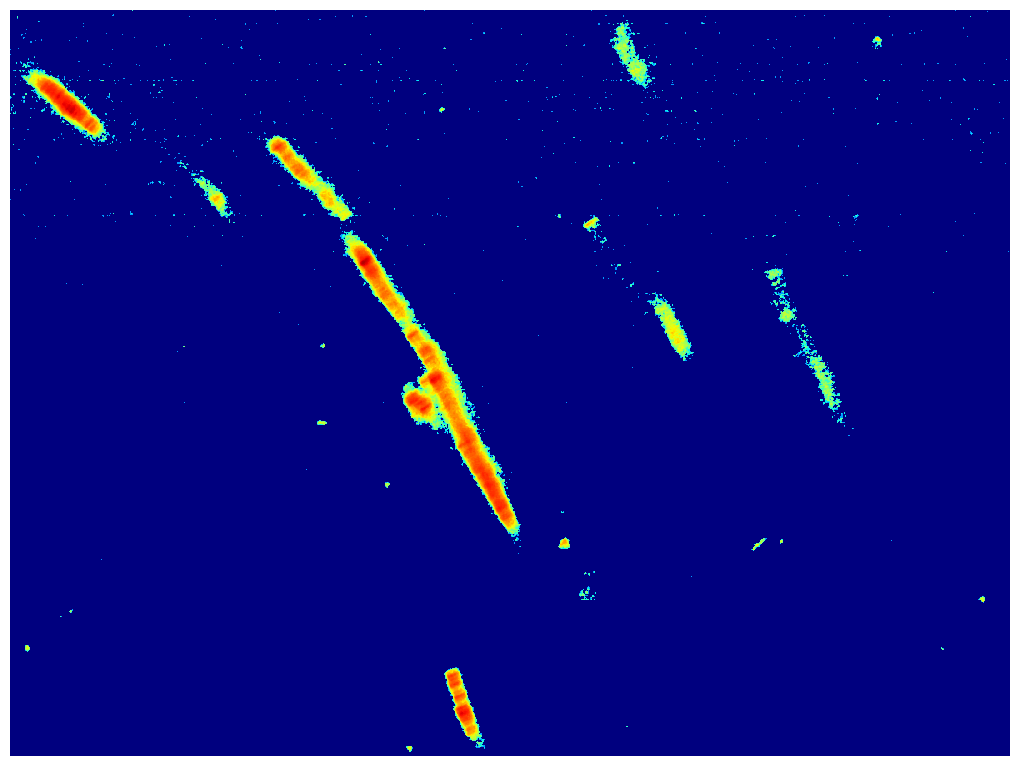

In [64]:
for N in np.linspace(900,1000,1):
    N = int(N)

    with h5py.File(datapath + "scan-0199_orca.h5", 'r') as f:
        dataset = f['entry/instrument/orca/data']
        detector_image = dataset[N:N+1].mean(axis=0)
    #detector_image = gaussian_filter(detector_image, sigma=2.0)
    from scipy.ndimage import median_filter
    detector_image = median_filter(detector_image, size=5)

    fig, ax = plt.subplots(figsize=(10, 10))


    # transparent background
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    from matplotlib.colors import LogNorm
    eps = 203
    ax.imshow(
        np.clip(detector_image[950:,:2200]-eps, a_min=0.1, a_max = 1000000),
        interpolation='nearest',
        cmap='jet',
        norm=LogNorm(vmin=0.1, vmax=400),
        origin='lower',
    )
    # remove everything
    ax.axis("off")

    # remove all margins
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.savefig('post_reconstruction_analysis/orca_plot_scan199_frame150_to_154.png', dpi=500, 
                transparent=True,
                bbox_inches="tight",
                pad_inches=0,)
    plt.show()